In [1]:
import argparse
import os
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_curve, auc
from utils.model_utils import load_train_test
from utils.visualize import plot_per_label_heatmap, plot_model_comparison


In [2]:
FIGURE_DPI = 150
OUTPUT_DIR = 'results/figures'
MODEL_DISPLAY_NAMES = {
    'logistic': 'Baseline LR',
    'logistic_ridge': 'Ridge (L2)',
    'logistic_lasso': 'Lasso (L1)',
    'LDA': 'LDA',
    'random_forest': 'Random Forest',
    'SVM': 'SVM',
    'MLP': 'MLP'
}
LABEL_NAMES = ['Adrenal', 'Bone', 'CNS', 'Liver', 'LN', 'Lung', 'Pleura']

def load_eval(feature_set: str) -> pd.DataFrame:
    """Load evaluation CSV and add MLP results if genomic."""
    path = f'results/evaluation/multilabel/evaluation_{feature_set}.csv'
    df = pd.read_csv(path, index_col=0)

    # need to merge MLP results if genomic pipeline since in separate script
    mlp_path = f'results/evaluation/multilabel/evaluation_{feature_set}_mlp.csv'
    if os.path.exists(mlp_path):
        mlp = pd.read_csv(mlp_path, index_col=0)
        df = pd.concat([df, mlp], axis=1)

    # rename columns to clean display names
    df.columns = [MODEL_DISPLAY_NAMES.get(c, c) for c in df.columns]
    return df

def load_models(feature_set: str, task) -> dict:
    '''loads a fitted model'''
    # load from feature-set specific subfolder
    path = Path(f'models/fitted_models/{feature_set}/{task}')
    models = {}
    for item in sorted(path.iterdir()):
        if item.is_file() and item.suffix == '.pkl' and not item.stem.startswith('gridsearch'):
            model = joblib.load(str(item))
            print(f"Loading: {item}")

            model_name = item.stem.replace(f'_{feature_set}', '')
            models[model_name] = model
    return models

def save_figure(fig, name: str, feature_set: str):
    """Save figure to results/figures/."""
    if feature_set not in ['clinical', 'genomic', 'combined']:
        dir = f'{OUTPUT_DIR}/other'

    else: dir = f'{OUTPUT_DIR}/{feature_set}/'
    os.makedirs(dir, exist_ok=True)
    path = os.path.join(dir, f'{feature_set}_{name}.png')
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.close(fig)


def ROC_panel(feature_sets: list, task: str, model_dicts: dict):

    fig, axes = plt.subplots(
        1, len(feature_sets),
        figsize=(6 * len(feature_sets), 6),
        sharex=True, sharey=True
    )

    if len(feature_sets) == 1:
        axes = [axes]

    all_handles = None
    all_labels = None

    for i, (ax, feature_set) in enumerate(zip(axes, feature_sets)):

        x_path = f'data/processed/X_{feature_set}.csv'
        y_path = f'data/processed/y_{task}.csv'

        _, X_test, _, y_test = load_train_test(x_path, y_path, scale=True)

        if task != 'multilabel':
            y_test = y_test.ravel()

        models = model_dicts[feature_set]

        for model_name, model in models.items():

            try:
                y_scores = model.predict_proba(X_test)[:, 1]
            except AttributeError:
                y_scores = model.decision_function(X_test)

            fpr, tpr, _ = roc_curve(y_test, y_scores)
            roc_auc = auc(fpr, tpr)

            ax.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.2f})")

        # diagonal baseline
        ax.plot([0, 1], [0, 1], 'k--', linewidth=1)

    titles = ['Clinical', 'Genomic', 'Combined', 'Combined w/ Interaction']

    for i, (title, ax) in enumerate(zip(titles, axes)):

        # title per subplot
        ax.set_title(title, fontsize=11, fontweight='bold')

        # axis limits per subplot
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        # panel label (A, B, C, D)
        ax.text(
            -0.12, 1.05,
            f"({chr(65 + i)})",
            transform=ax.transAxes,
            fontsize=12,
            fontweight='bold',
            va='top',
            ha='right'
        )
        ax.grid(alpha=0.3, linestyle='--')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # capture legend ONLY from first axis
        if all_handles is None:
            all_handles, all_labels = ax.get_legend_handles_labels()

    # axis labels only on edges (cleaner panel style)
    axes[0].set_ylabel("True Positive Rate", fontsize=10)
    for ax in axes:
        ax.set_xlabel("False Positive Rate", fontsize=10)

    # 🔥 ONE GLOBAL LEGEND
    fig.legend(
        all_handles,
        all_labels,
        loc='lower right',
        ncol=1,
        fontsize=12,
        frameon=False,
        labelspacing=0.8,
        handletextpad=0.6,
        bbox_to_anchor=(1, .1),  # ↑ move up
    )


    fig.tight_layout(rect=[0, 0, 1, 0.90])

    save_figure(fig, 'roc_panel_binary', 'other')
    fig.savefig("roc_panel.pdf", bbox_inches="tight")
    return fig


In [3]:
model_dicts = {
    'clinical': load_models('clinical', 'binary'),
    'genomic': load_models('genomic', 'binary'),
    'combined': load_models('combined', 'binary'),
    'combined_interact': load_models('combined_interact', 'binary')
}

fig = ROC_panel(['clinical', 'genomic', 'combined', 'combined_interact'], 'binary', model_dicts)


Loading: models/fitted_models/clinical/binary/LDA_clinical.pkl
Loading: models/fitted_models/clinical/binary/SVM_clinical.pkl
Loading: models/fitted_models/clinical/binary/logistic_clinical.pkl
Loading: models/fitted_models/clinical/binary/logistic_lasso_clinical.pkl
Loading: models/fitted_models/clinical/binary/logistic_ridge_clinical.pkl
Loading: models/fitted_models/clinical/binary/random_forest_clinical.pkl
Loading: models/fitted_models/genomic/binary/LDA_genomic.pkl
Loading: models/fitted_models/genomic/binary/SVM_genomic.pkl
Loading: models/fitted_models/genomic/binary/logistic_genomic.pkl
Loading: models/fitted_models/genomic/binary/logistic_lasso_genomic.pkl
Loading: models/fitted_models/genomic/binary/logistic_ridge_genomic.pkl
Loading: models/fitted_models/genomic/binary/random_forest_genomic.pkl
Loading: models/fitted_models/combined/binary/LDA_combined.pkl
Loading: models/fitted_models/combined/binary/SVM_combined.pkl
Loading: models/fitted_models/combined/binary/logistic_c

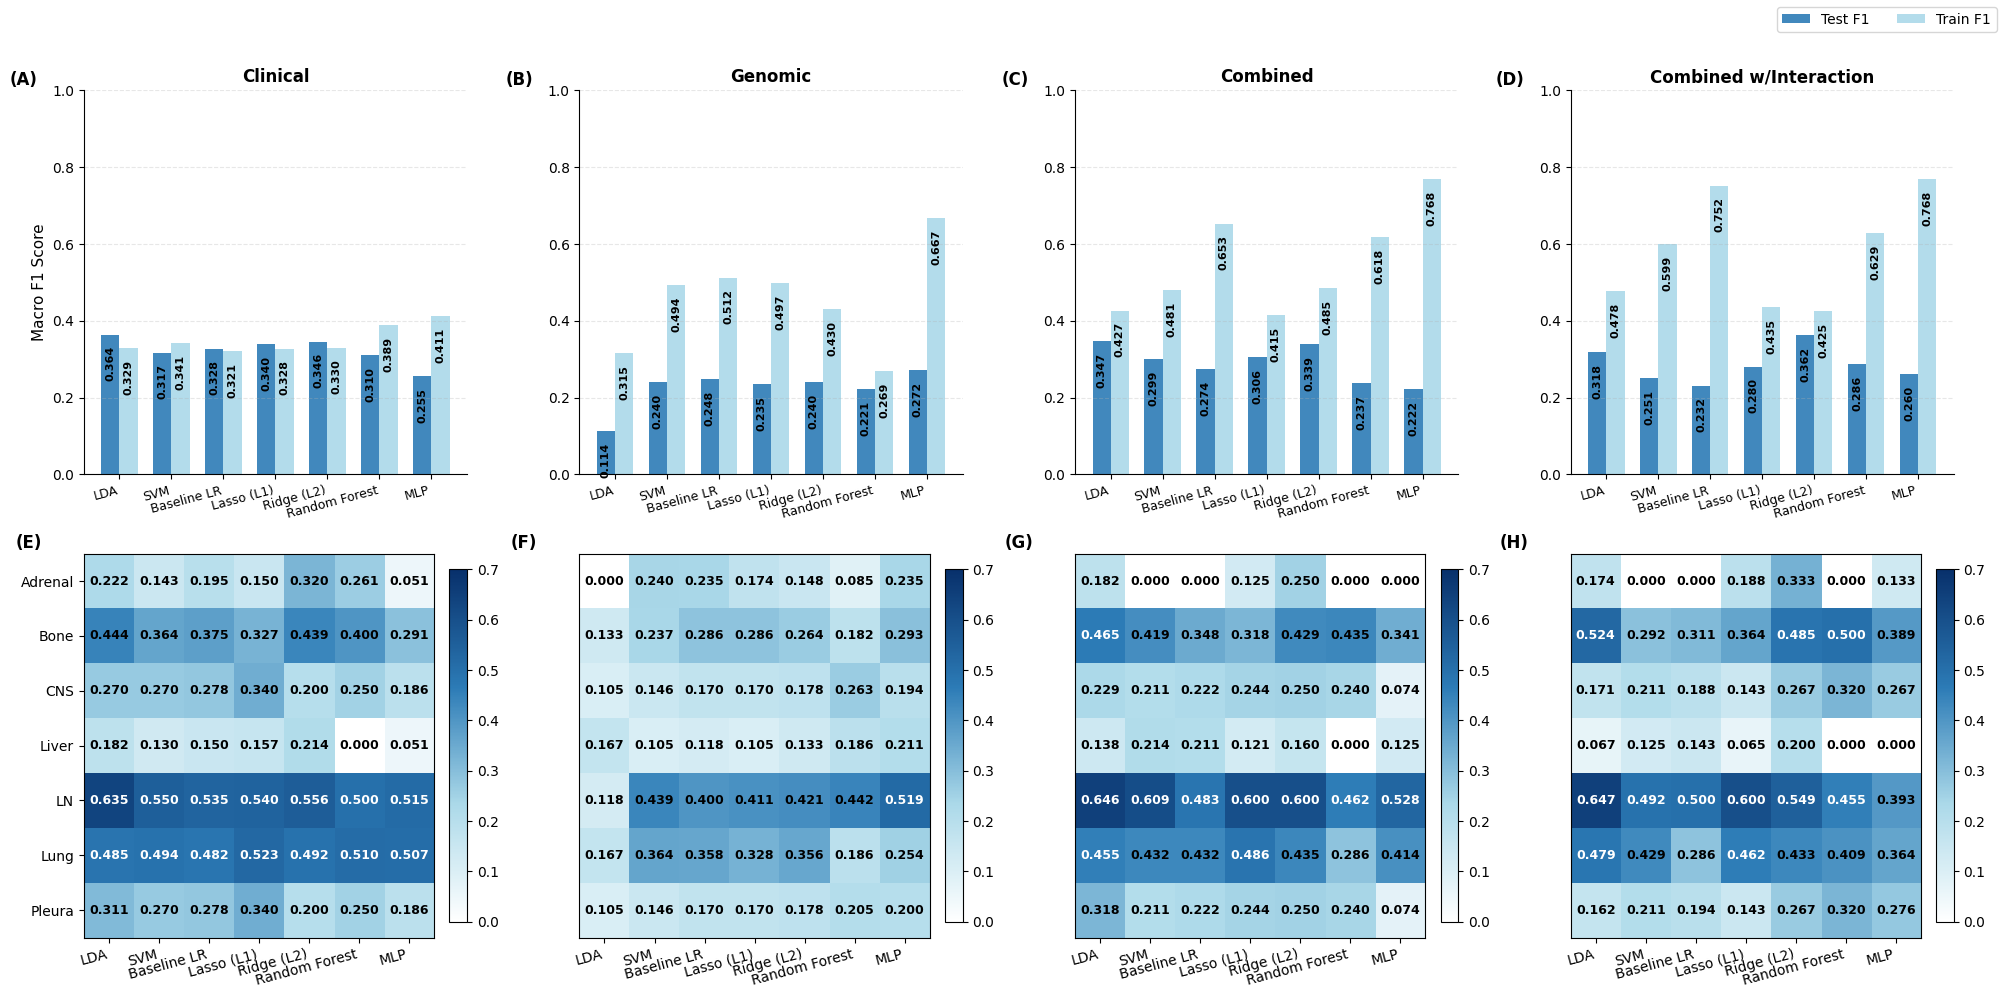

In [4]:
import matplotlib.pyplot as plt
df_clinical = load_eval('clinical')
df_genomic = load_eval('genomic')
df_combined = load_eval('combined')
df_combined_interact = load_eval('combined_interact')

fig, axes = plt.subplots(2, 4, figsize=(20,10))

# ---- Row 1: Model comparison ----
plot_model_comparison(df_clinical, 'clinical', ax=axes[0, 0])
plot_model_comparison(df_genomic, 'genomic', ax=axes[0, 1])
plot_model_comparison(df_combined, 'combined', ax=axes[0, 2])
plot_model_comparison(df_combined_interact, 'combined_interact', ax=axes[0, 3])
axes[0][0].set_ylabel('Macro F1 Score', fontsize=11) 

# ---- Row 2: Heatmaps ----
plot_per_label_heatmap('clinical', ax=axes[1, 0])
plot_per_label_heatmap('genomic', ax=axes[1, 1])
plot_per_label_heatmap('combined', ax=axes[1, 2])
plot_per_label_heatmap('combined_interact', ax=axes[1, 3])
axes[1,0].set_yticks(range(len(LABEL_NAMES)))
axes[1,0].set_yticklabels(LABEL_NAMES, fontsize=10)
# ---- Subplot labels ----
titles = [
    "Clinical", "Genomic", "Combined", "Combined w/Interaction",
    "", "", "", ""
]

for i, (ax, title) in enumerate(zip(axes.flatten(), titles)):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.text(
        -0.12, 1.05,
        f"({chr(65 + i)})",
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='right'
    )
# ---- Global title ----
# fig.suptitle("Model Performance and Per-Label Analysis Across Feature Sets",
#              fontsize=16)

# ---- Shared legend (for bar charts) ----
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for title + legend
plt.savefig("multilabel_panel.pdf", bbox_inches="tight")

plt.show()
